# **Cuaderno 3.2 -- Shallow neural networks II**

El propósito de este cuaderno es familiarizarse con las redes neuronales superficiales con entradas 2D. Se trabaja a través de un ejemplo similar a la figura 3.8 y se experimenta con diferentes funciones de activación. <br><br>

Revise las celdas a continuación, ejecutando cada una a su vez. En varios lugares verá las palabras "TAREA PENDIENTE". Siga las instrucciones en estos lugares y escriba código para completar las funciones. También hay preguntas intercaladas en el texto.

Contácteme en udlbookmail@gmail.com si encuentra algún error o tiene alguna sugerencia.

In [6]:
# Importa la librería de matemáticas
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt

In [7]:
# Código para dibujar funciones 2D -- léalo para saber qué está pasando, pero no tiene que modificarlo
def draw_2D_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# Traza la red neuronal superficial. Asumiremos que la entrada está en el rango [0,10],[0,10] y la salida en [-10,10]
def plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3):

  fig, ax = plt.subplots(3,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivación')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivación')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivación')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activación')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activación')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activación')
  draw_2D_function(ax[2,0], x1,x2,w_act_1); ax[2,0].set_title('Activación ponderada')
  draw_2D_function(ax[2,1], x1,x2,w_act_2); ax[2,1].set_title('Activación ponderada')
  draw_2D_function(ax[2,2], x1,x2,w_act_3); ax[2,2].set_title('Activación ponderada')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y)
  ax.set_title('Salida de la red, $y$')
  ax.set_aspect(1.0)
  plt.show()

In [8]:
# Define la función Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [9]:
# Define una red neuronal superficial con dos entradas, una salida y tres unidades ocultas
def shallow_2_1_3(x1,x2, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32):
  # TAREA PENDIENTE: Reemplace las líneas siguientes para calcular las tres funciones lineales iniciales
  # (figura 3.8a-c) a partir de los parámetros theta. Estas son las preactivaciones
  pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
  pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
  pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

  # Páselos a través de la función ReLU para calcular las activaciones como en
  # la figura 3.8 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # TAREA PENDIENTE: Reemplace el código siguiente para ponderar las activaciones usando phi1, phi2 y phi3
  # Para crear el equivalente de la figura 3.8 g-i
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  # TAREA PENDIENTE: Reemplace el código siguiente para combinar las activaciones ponderadas y añadir
  # phi_0 para crear la salida como en la figura 3.8j
  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Devuelve todo lo que hemos calculado
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

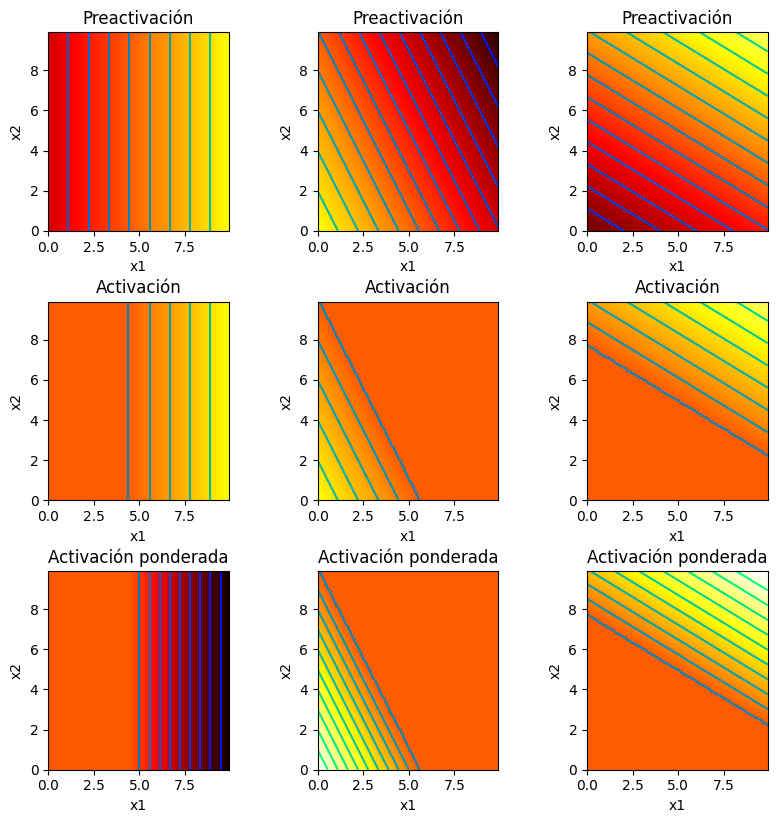

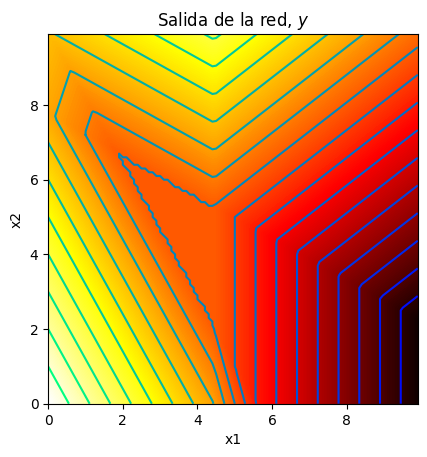

In [10]:
# Ahora definamos algunos parámetros y ejecutemos la red neuronal
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_0 = 0.0; phi_1 = -2.0; phi_2 = 2.0; phi_3 = 1.5

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_2_1_3(x1,x2, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# Y luego lo trazamos
plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3)

¿Cuántos politopos lineales diferentes son creados por este modelo? Identifique cada uno en la salida de la red.

Para esta cuestión extenderemos este modelo para tener dos salidas $y_1$ y $y_2$, cada una de las cuales puede visualizarse con un mapa de calor separado. Ahora tendrá conjuntos de parámetros $\phi_{10}, \phi_{11},\phi_{12}$ y $\phi_{20}, \phi_{21},\phi_{22}$ que corresponden a cada una de estas salidas.

In [11]:
# Traza la red neuronal superficial. Asumiremos que la entrada está en el rango [0,10],[0,10] y la salida en [-10,10]
def plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23):

  # Traza los gráficos intermedios si la bandera está activada
  fig, ax = plt.subplots(4,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivación')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivación')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivación')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activación')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activación')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activación')
  draw_2D_function(ax[2,0], x1,x2,w_act_11); ax[2,0].set_title('Activación Ponderada 1')
  draw_2D_function(ax[2,1], x1,x2,w_act_12); ax[2,1].set_title('Activación Ponderada 1')
  draw_2D_function(ax[2,2], x1,x2,w_act_13); ax[2,2].set_title('Activación Ponderada 1')
  draw_2D_function(ax[3,0], x1,x2,w_act_21); ax[3,0].set_title('Activación Ponderada 2')
  draw_2D_function(ax[3,1], x1,x2,w_act_22); ax[3,1].set_title('Activación Ponderada 2')
  draw_2D_function(ax[3,2], x1,x2,w_act_23); ax[3,2].set_title('Activación Ponderada 2')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y1)
  ax.set_title('Salida de la red, $y_1$')
  ax.set_aspect(1.0)
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y2)
  ax.set_title('Salida de la red, $y_2$')
  ax.set_aspect(1.0)
  plt.show()

In [13]:
# Define una red neuronal superficial con dos entradas, dos salidas y tres unidades ocultas
def shallow_2_2_3(x1,x2, activation_fn, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32):

  # TAREA PENDIENTE -- escriba esta función -- reemplace el código dummy a continuación
  pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
  pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
  pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_11 = phi_11 * act_1
  w_act_12 = phi_12 * act_2
  w_act_13 = phi_13 * act_3

  w_act_21 = phi_21 * act_1
  w_act_22 = phi_22 * act_2
  w_act_23 = phi_23 * act_3

  y1 = phi_10 + w_act_11 + w_act_12 + w_act_13
  y2 = phi_20 + w_act_21 + w_act_22 + w_act_23


  # Devuelve todo lo que hemos calculado
  return y1,y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23

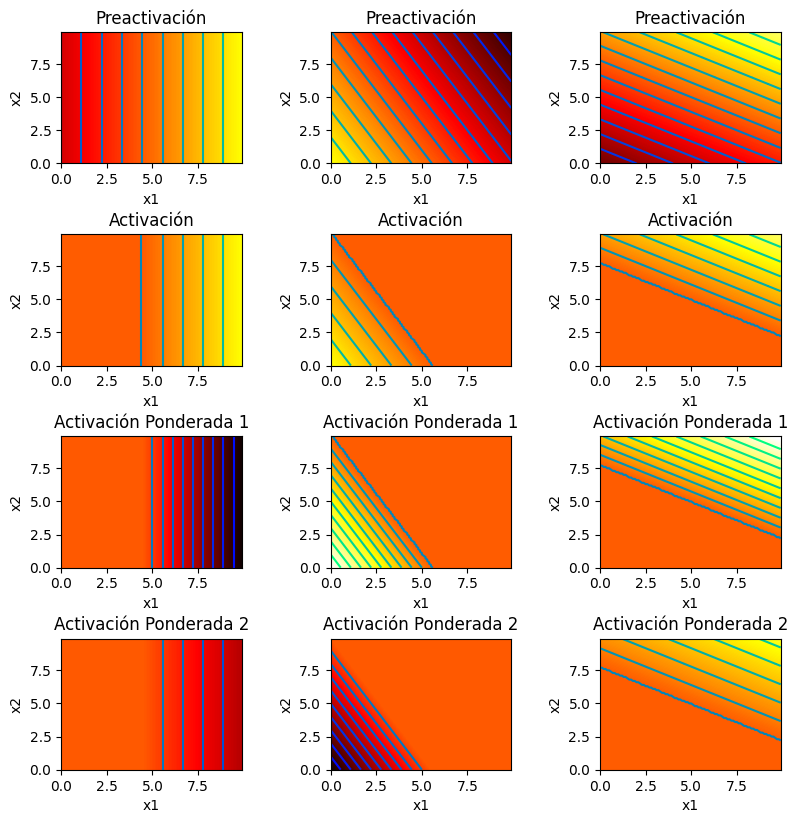

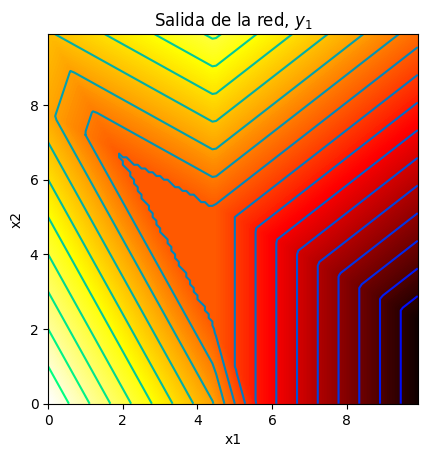

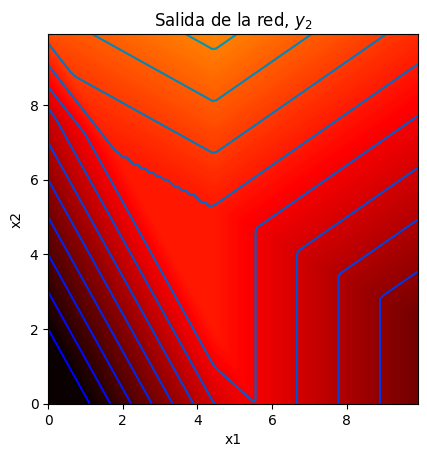

In [14]:
# Ahora definamos algunos parámetros y ejecutemos la red neuronal
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_10 = 0.0; phi_11 = -2.0; phi_12 = 2.0; phi_13 = 1.5
phi_20 = -2.0; phi_21 = -1.0; phi_22 = -2.0; phi_23 = 0.8

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23 = \
    shallow_2_2_3(x1,x2, ReLU, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# Y luego lo trazamos
plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23)